# DriveBuddyAI: Pav Bhaji Classification Using Instagram Post Metadata

### Machine Learning Classification from Social Media Metadata

This project builds a machine learning pipeline to classify Instagram posts into **Pav Bhaji** and **Non-Pav Bhaji** classes using the metadata provided with the dataset.

The image folders are used only to obtain the ground-truth labels. The actual classifier works on the available Instagram metadata, mainly **captions and hashtags**, instead of using image pixels.

### Objectives

- Build a labelled dataset by matching Instagram metadata with the provided image labels.
- Explore the available captions, hashtags and post metadata.
- Clean and prepare the text for classification.
- Convert text into TF-IDF features.
- Compare multiple machine learning models.
- Handle the class imbalance present in the labelled data.
- Evaluate the final model using accuracy, precision, recall, F1-score and ROC-AUC.
- Inspect important text features and analyse classification errors.
- Create a reusable function for predicting the class of new Instagram metadata.

### Classification Target

| Label | Class |
|---|---|
| `0` | Non-Pav Bhaji |
| `1` | Pav Bhaji |

> **Approach note:** The model is intentionally metadata-based. It does not use CNN/image-pixel features, so the results reflect how much information can be extracted from Instagram captions and hashtags.

In [32]:
# Core Python libraries
import os
import json
import re
import zipfile
import urllib.parse

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

In [2]:
zip_path = "/content/dataset.zip"
extract_path = "/content/drivebuddy_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [3]:
json_path = os.path.join(
    extract_path,
    "dataset",
    "pavbhaji.json"
)

with open(json_path, "r", encoding="utf-8") as f:
    posts = json.load(f)

print(f"Total JSON records: {len(posts)}")

Total JSON records: 1500


In [4]:
print("Available fields:")
for field in posts[0].keys():
    print("-", field)

Available fields:
- dimensions
- display_url
- edge_liked_by
- edge_media_preview_like
- edge_media_to_caption
- edge_media_to_comment
- id
- is_video
- location
- owner
- shortcode
- tags
- taken_at_timestamp
- thumbnail_resources
- thumbnail_src
- urls
- video_view_count


In [5]:
image_root = os.path.join(
    extract_path,
    "dataset",
    "images"
)

image_files = {}

for label in ["0", "1"]:
    folder = os.path.join(image_root, label)

    for filename in os.listdir(folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files[filename] = int(label)

print("Labelled images:", len(image_files))
print("Class distribution:")
print(pd.Series(image_files.values()).value_counts().sort_index())

Labelled images: 452
Class distribution:
0    269
1    183
Name: count, dtype: int64


In [6]:
# Match image labels with the corresponding Instagram metadata
rows = []

for post in posts:

    display_url = post.get("display_url", "")

    filename = os.path.basename(
        urllib.parse.urlparse(display_url).path
    )

    if filename not in image_files:
        continue

    caption_edges = (
        post.get("edge_media_to_caption", {})
            .get("edges", [])
    )

    caption = " ".join(
        edge.get("node", {}).get("text", "")
        for edge in caption_edges
    )

    tags = post.get("tags") or []

    rows.append({
        "image_file": filename,
        "label": image_files[filename],
        "caption": caption,
        "tags": " ".join(tags),
        "likes": post.get("edge_liked_by", {}).get("count", 0),
        "comments": post.get("edge_media_to_comment", {}).get("count", 0),
        "is_video": int(post.get("is_video", False)),
        "has_location": int(post.get("location") is not None),
        "timestamp": post.get("taken_at_timestamp")
    })

df = pd.DataFrame(rows)

print("Final labelled dataset:", df.shape)
df.head()

Final labelled dataset: (452, 9)


,image_file,label,caption,tags,likes,comments,is_video,has_location,timestamp
0,39790065_708138802879611_4373499256883904512_n...,0,Chicken Tikka 😍😋\n.\n.\n.\nFollow @dilli_ki_te...,westbengal iphone delhifoodie sokolkata mumbai...,45,5,0,0,1535379959
1,39205669_548076665624561_2856530375738392576_n...,1,"Hello frandz,\npav bhaji khaalo\nGaram hai 😜\n...",foodgram foodphotography foodblogger foodmania...,215,0,0,1,1535378509
2,39928567_2025694197741778_2817802553157661723_...,0,Follow @dilliciousfoodie \n@dilliciousfoodie \...,foodphotography bhaji pasta fries f52grams ind...,46,0,0,1,1535377934
3,39991006_472180219962850_7601786252118982656_n...,0,We’ve got you some delicious evening snacks💯\n...,UpcyclingFood Twist LeftoverPavBhajiBreadPakod...,741,2,0,0,1535376388
4,37158549_528309647598249_6068909533663592448_n...,0,People who love food are the best 😁\n.\n.\n.\n...,foodphotography lonidosa tbt foodie maharashtr...,28,0,0,1,1535376196


## 1. Dataset Overview

The dataset contains Instagram post metadata collected from posts related to `#pavbhaji`.

The task is to classify whether a post belongs to the **Pav Bhaji** or **Non-Pav Bhaji** class. The JSON file contains the post metadata, while the supplied images are already divided into the two label folders:

- `1` → Pav Bhaji
- `0` → Non-Pav Bhaji

I first match the image filename with the corresponding Instagram post so that the metadata and ground-truth label are available in the same dataframe.

In [7]:
print("Number of labelled records:", len(df))

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nClass proportions:")
print(df["label"].value_counts(normalize=True).round(3))

Number of labelled records: 452

Class distribution:
label
0    269
1    183
Name: count, dtype: int64

Class proportions:
label
0    0.595
1    0.405
Name: proportion, dtype: float64


## 2. Class Distribution

Before training, I checked the number of samples in each class. This is important because an uneven class distribution can affect the interpretation of accuracy and can cause a model to favour the larger class.

In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
image_file      0
label           0
caption         0
tags            0
likes           0
comments        0
is_video        0
has_location    0
timestamp       0
dtype: int64


## 3. Missing Value Analysis

I checked missing values in the available metadata before preprocessing. This helps avoid problems when combining the text fields and gives a clear idea of which fields are actually usable for modelling.

## 4. Basic Feature Analysis

I checked the basic characteristics of the available metadata, including caption length, number of tags, likes and comments.

This gives a quick view of the data before the text modelling stage and helps identify fields that may be useful for analysis.

In [9]:
df["caption"] = df["caption"].fillna("").astype(str)
df["tags"] = df["tags"].fillna("").astype(str)

df["caption_length"] = df["caption"].str.len()
df["tag_count"] = df["tags"].str.split().str.len()

df[["caption_length", "tag_count", "likes", "comments"]].describe()

,caption_length,tag_count,likes,comments
count,452.000000,452.000000,452.000000,452.000000
mean,415.752212,19.792035,241.595133,4.946903
std,288.654599,9.385847,773.737190,11.513679
min,9.000000,0.000000,0.000000,0.000000
25%,232.250000,12.000000,25.000000,0.000000
50%,383.000000,23.000000,53.000000,2.000000
75%,532.250000,28.000000,150.000000,5.000000
max,1859.000000,30.000000,11474.000000,125.000000


## 5. Checking the Pav Bhaji Keyword

Because the original posts were collected using a `#pavbhaji` criterion, I checked how often the Pav Bhaji keyword occurs in the available captions and hashtags.

This is an important check: if the collection keyword appears directly in the text, it can make classification easier and may not represent a general food-classification signal. I therefore treat this as an analysis point rather than relying on the keyword alone.

In [10]:
keyword_pattern = r"\bpavbhaji\b"

df["has_pavbhaji_keyword"] = (
    (df["caption"] + " " + df["tags"])
    .str.lower()
    .str.contains(keyword_pattern, regex=True, na=False)
)

print(
    pd.crosstab(
        df["label"],
        df["has_pavbhaji_keyword"],
        margins=True
    )
)

has_pavbhaji_keyword  False  True  All
label                                 
0                         6   263  269
1                         3   180  183
All                       9   443  452


## 6. Sample Text Inspection

I inspected examples from both classes to understand the captions and hashtags the model is working with.

This also helps identify common patterns such as food terms, locations, promotional text and generic Instagram content.

In [12]:
for label in [0, 1]:
    print(f"\n{'=' * 60}")
    print(f"CLASS {label} EXAMPLES")
    print(f"{'=' * 60}")

    sample = df[df["label"] == label][
        ["caption", "tags"]
    ].head(5)

    for _, row in sample.iterrows():
        print("\nCaption:", row["caption"][:300])
        print("Tags:", row["tags"][:300])


CLASS 0 EXAMPLES

Caption: Chicken Tikka 😍😋
.
.
.
Follow @dilli_ki_teekhi_mirchi .
.
.
@zingyzest 
@saadidilli 
@thegreatindianfoodie 
@khaata_rahe_mera_dil 
@khau_gali_foodie 
@dillifoodjunkie 
@foodiebaniya 
@dilsefoodie 
@dillikabhukkad 
@whatdillieats 
@bhukkhadbybirth 
@delhifoodwalks 
@dillifoodies 
@thefood.vlogger 
@d
Tags: westbengal iphone delhifoodie sokolkata mumbaifoodie mumbaifoodbloggers waiwai chicken chickentikka delhieater iphonephotography foodporn platter delhifood nomnom nepal bengluru nom mumbaifoodblogger delhifoodblogger somumbai mumbaifood chickentikkamasala pavbhaji foodtalkindia delhi_igers delhifood

Caption: Follow @dilliciousfoodie 
@dilliciousfoodie 
@dilliciousfoodie 
@dilliciousfoodie 
@dilliciousfoodie 
@dilliciousfoodie .
.
.
➖➖➖➖
.
.
#dillifoodjunkie #foodforlife #pasta #food #pavbhaji #chicken #butterchicken #indianfood #india #tasty #foodgasm #yummyinmytummy #foodphotography #streetfood #lifest
Tags: foodphotography bhaji pasta fries f52grams indi

## 7. Text Preprocessing

The main predictive information comes from the caption and hashtag text. Before applying TF-IDF, I combine these fields and clean the text.

The preprocessing handles common Instagram text such as URLs, mentions, punctuation, extra spaces and other noise. The text is converted to lowercase so that the same word is treated consistently.

I also keep the Pav Bhaji keyword analysis separate because it is related to the way the dataset was collected.

In [13]:
df["text"] = (
    df["caption"].fillna("") + " " +
    df["tags"].fillna("")
).str.lower()

df[["caption", "tags", "text"]].head()

,caption,tags,text
0,Chicken Tikka 😍😋\n.\n.\n.\nFollow @dilli_ki_te...,westbengal iphone delhifoodie sokolkata mumbai...,chicken tikka 😍😋\n.\n.\n.\nfollow @dilli_ki_te...
1,"Hello frandz,\npav bhaji khaalo\nGaram hai 😜\n...",foodgram foodphotography foodblogger foodmania...,"hello frandz,\npav bhaji khaalo\ngaram hai 😜\n..."
2,Follow @dilliciousfoodie \n@dilliciousfoodie \...,foodphotography bhaji pasta fries f52grams ind...,follow @dilliciousfoodie \n@dilliciousfoodie \...
3,We’ve got you some delicious evening snacks💯\n...,UpcyclingFood Twist LeftoverPavBhajiBreadPakod...,we’ve got you some delicious evening snacks💯\n...
4,People who love food are the best 😁\n.\n.\n.\n...,foodphotography lonidosa tbt foodie maharashtr...,people who love food are the best 😁\n.\n.\n.\n...


In [14]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove the collection keyword and common variants
    text = re.sub(r"#?\bpav\s*bhaji\b", " ", text)
    text = re.sub(r"\b\w*pavbhaji\w*\b", " ", text)

    # Remove mentions
    text = re.sub(r"@\w+", " ", text)

    # Remove non-alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,chicken tikka 😍😋\n.\n.\n.\nfollow @dilli_ki_te...,chicken tikka follow vlogger chicken chickenti...
1,"hello frandz,\npav bhaji khaalo\ngaram hai 😜\n...",hello frandz khaalo garam hai ye achhi thi at ...
2,follow @dilliciousfoodie \n@dilliciousfoodie \...,follow dillifoodjunkie foodforlife pasta food ...
3,we’ve got you some delicious evening snacks💯\n...,we ve got you some delicious evening snacks br...
4,people who love food are the best 😁\n.\n.\n.\n...,people who love food are the best food foods f...


## 8. Features Used for Classification

The dataset contains several types of metadata:

| Feature | Use in the project |
|---|---|
| Caption | Main textual description of the post |
| Tags / Hashtags | Additional text and topic information |
| Likes | Post engagement information |
| Comments | User interaction information |
| Is video | Post-format information |
| Location | Available contextual information |
| Timestamp | Time-related metadata |

For the main classifier, **caption + hashtags** are converted into TF-IDF features. The other metadata fields are inspected as supporting information but are not mixed into the main text model without a separate validation experiment.

## 9. Train-Test Split

I use an 80:20 train-test split with `stratify=y`.

The training set is used to fit the vectorizer and models, while the test set is kept separate for final evaluation. Stratification keeps the class proportions similar in both sets.

In [15]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 361
Testing samples: 91


## 10. TF-IDF Feature Extraction

TF-IDF converts the cleaned captions and hashtags into numerical features that can be used by the classifiers.

I use both **unigrams and bigrams** so the model can learn individual words as well as short phrases. The vectorizer is fitted only on the training data and then applied to the test data.

## 11. Logistic Regression

Logistic Regression is used as the first baseline model.

It is a good fit for sparse TF-IDF text features and also gives interpretable coefficients, which are useful later when checking which words are associated with each class.

In [16]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (361, 3495)
Testing TF-IDF shape: (91, 3495)


In [17]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print(classification_report(
    y_test,
    lr_pred,
    target_names=["Non-Pav Bhaji", "Pav Bhaji"]
))

               precision    recall  f1-score   support

Non-Pav Bhaji       0.63      0.85      0.72        54
    Pav Bhaji       0.56      0.27      0.36        37

     accuracy                           0.62        91
    macro avg       0.59      0.56      0.54        91
 weighted avg       0.60      0.62      0.58        91



## 12. Linear SVM

I also test a Linear Support Vector Machine. Linear SVM is commonly used with high-dimensional sparse text features and gives a useful comparison against Logistic Regression.

In [18]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print(classification_report(
    y_test,
    svm_pred,
    target_names=["Non-Pav Bhaji", "Pav Bhaji"]
))

               precision    recall  f1-score   support

Non-Pav Bhaji       0.65      0.65      0.65        54
    Pav Bhaji       0.49      0.49      0.49        37

     accuracy                           0.58        91
    macro avg       0.57      0.57      0.57        91
 weighted avg       0.58      0.58      0.58        91



## 13. Model Comparison

The baseline models are compared using **accuracy, precision, recall and F1-score**.

I do not rely on accuracy alone because the two classes are not exactly equal in size. F1-score is useful here because it considers both precision and recall.

In [19]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, svm_pred)
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.615,0.556,0.270,0.364
1,Linear SVM,0.582,0.486,0.486,0.486


## 14. Initial Model Selection

The initial comparison is used as a baseline. Instead of selecting a final model immediately, I continue with feature selection and class-weighted models.

This gives a more useful comparison because the labelled dataset has some class imbalance.

In [20]:
# Trained the final model on the training data

final_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_final = final_vectorizer.fit_transform(X_train)
X_test_final = final_vectorizer.transform(X_test)

final_model = LinearSVC(random_state=42)

final_model.fit(X_train_final, y_train)

final_pred = final_model.predict(X_test_final)

print(classification_report(
    y_test,
    final_pred,
    target_names=["Non-Pav Bhaji", "Pav Bhaji"]
))

               precision    recall  f1-score   support

Non-Pav Bhaji       0.65      0.65      0.65        54
    Pav Bhaji       0.49      0.49      0.49        37

     accuracy                           0.58        91
    macro avg       0.57      0.57      0.57        91
 weighted avg       0.58      0.58      0.58        91



## 15. Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each class.

It is especially useful here because it shows whether the model is missing Pav Bhaji posts or incorrectly marking Non-Pav Bhaji posts as Pav Bhaji.

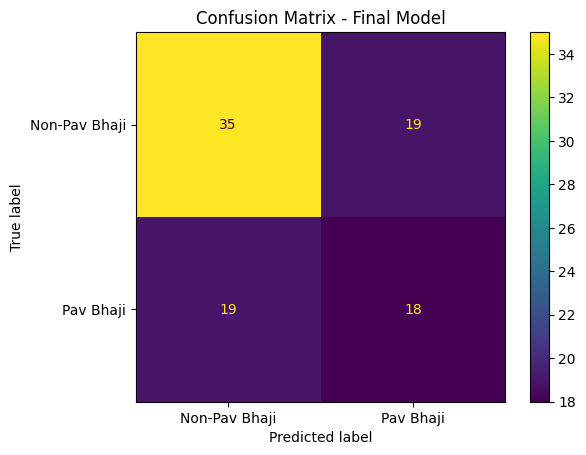

In [21]:
cm = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Pav Bhaji", "Pav Bhaji"]
)

disp.plot()
plt.title("Confusion Matrix - Final Model")
plt.show()

## 16. Feature Engineering and Relevance

The main modelling input is **caption + hashtags** because these fields directly describe the Instagram post.

Other available metadata includes likes, comments, video status and location. These fields are useful for understanding the dataset, but the final model is kept as a text-based classifier so that the effect of the textual information can be evaluated clearly.

The later feature-selection step reduces the TF-IDF space to the most informative terms before comparing additional models.

In [22]:
# Summarise the metadata fields used for analysis

feature_summary = pd.DataFrame({
    "Feature": [
        "Caption",
        "Tags",
        "Likes",
        "Comments",
        "Is Video",
        "Has Location"
    ],
    "Data Type": [
        "Text",
        "Text",
        "Numeric",
        "Numeric",
        "Binary",
        "Binary"
    ],
    "Missing Values": [
        df["caption"].isna().sum(),
        df["tags"].isna().sum(),
        df["likes"].isna().sum(),
        df["comments"].isna().sum(),
        df["is_video"].isna().sum(),
        df["has_location"].isna().sum()
    ]
})

feature_summary

,Feature,Data Type,Missing Values
0,Caption,Text,0
1,Tags,Text,0
2,Likes,Numeric,0
3,Comments,Numeric,0
4,Is Video,Binary,0
5,Has Location,Binary,0


## 17. Error Analysis

After selecting the final model, I inspect the misclassified test examples.

Some errors are expected because the classifier only sees metadata. A Non-Pav Bhaji post can contain Pav Bhaji-related words, while a genuine Pav Bhaji post may have very little useful food-related text.

The error analysis is therefore used to understand where a metadata-only approach has difficulty.

In [24]:
# Inspect misclassified test examples

misclassified = df.loc[y_test.index].copy()
misclassified["predicted_label"] = final_pred

misclassified = misclassified[
    misclassified["label"] != misclassified["predicted_label"]
]

misclassified[["caption", "tags", "label", "predicted_label"]].head(10)

,caption,tags,label,predicted_label
72,Rakhi special ❤️ Homemade Pav Bhaji 😊\n\nFollo...,rakhi nomnom saharanpur foodlover 2018 homeswe...,0,1
75,#cooking #pavbhaji #somethingnew,pavbhaji cooking somethingnew,0,1
185,The next time ur around Crawford market and hu...,foodofmumbai bhgfood foodmaniacindia delhifood...,1,0
386,Cheating the diet today also 😑 with these....⬅...,momos spicyfood food love indianfood streetfoo...,0,1
381,#pavbhaji #pavbhajilove,pavbhaji pavbhajilove,1,0
259,So this special dish was prepared yesterday ev...,surreyfood spices muddystilettos food eat surr...,0,1
419,#pavbhaji,pavbhaji,1,0
411,Pav Bhaji is a good Pav Bhaji when you aren't ...,foodlover foodphotography foodie pavbhaji yumm...,1,0
281,#repost @thedelhistreets😍😍\n#tag#pavbhajjilove...,repost butterbread indianstreetfood withgreenc...,1,0
373,"When it comes to love and food, nothing can be...",foodgram foodphotography delhincr foodmaniacin...,1,0


## 18. Prediction on New Instagram Metadata

The trained vectorizer and final classifier can be reused on a new Instagram caption and hashtag set.

The prediction function follows the same text transformation used during training. No image pixels are passed to the model.

In [25]:
def predict_pavbhaji(caption, tags):
    text = str(caption) + " " + str(tags)
    text_vector = final_vectorizer.transform([text])
    prediction = final_model.predict(text_vector)[0]

    if prediction == 1:
        return "Pav Bhaji"
    else:
        return "Not Pav Bhaji"


# Example
predict_pavbhaji(
    "Delicious street style pav bhaji with butter",
    "#food #streetfood #pavbhaji"
)

'Pav Bhaji'

## 19. Intermediate Conclusion

At this stage, the baseline experiments show that Instagram text contains useful information for separating the two classes, but the initial models are affected by the uneven class distribution.

The next steps strengthen the evaluation by applying TF-IDF feature selection, comparing an additional classifier, and testing class-weighted models before choosing the final model.

## 20. Additional Model Evaluation

To make the model comparison stronger, I apply **Chi-Square feature selection** to the TF-IDF representation and compare:

- Logistic Regression
- Linear SVM
- Multinomial Naive Bayes

All models use the same training and test split. ROC-AUC is also included to evaluate how well the models separate the two classes.

In [26]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score

# Select informative TF-IDF features
k = min(1000, X_train_final.shape[1])

selector = SelectKBest(score_func=chi2, k=k)

X_train_selected = selector.fit_transform(X_train_final, y_train)
X_test_selected = selector.transform(X_test_final)

print("Original TF-IDF features:", X_train_final.shape[1])
print("Selected features:", X_train_selected.shape[1])

Original TF-IDF features: 3495
Selected features: 1000


In [27]:
# Training and evaluating models using the selected TF-IDF features

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Linear SVM": LinearSVC(random_state=42),
    "Naive Bayes": MultinomialNB()
}

model_results = []

for name, model in models.items():
    model.fit(X_train_selected, y_train)
    pred = model.predict(X_test_selected)

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_test_selected)
        auc = roc_auc_score(y_test, scores)
    else:
        probabilities = model.predict_proba(X_test_selected)[:, 1]
        auc = roc_auc_score(y_test, probabilities)

    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": auc
    })

selected_results = pd.DataFrame(model_results).round(3)
selected_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.593,0.500,0.216,0.302,0.664
1,Linear SVM,0.560,0.452,0.378,0.412,0.634
2,Naive Bayes,0.582,0.481,0.351,0.406,0.646


## 21. Model Comparison After Feature Selection

The selected-feature models are compared using accuracy, precision, recall, F1-score and ROC-AUC.

This experiment checks whether reducing the TF-IDF feature space keeps the useful text information while removing less informative terms.

## 22. Handling Class Imbalance

The labelled data contains more Non-Pav Bhaji samples than Pav Bhaji samples.

To reduce the effect of this imbalance, I test class-weighted Logistic Regression and Linear SVM. With `class_weight="balanced"`, the model gives more weight to the smaller class during training.

The models are evaluated on the same held-out test set.

In [28]:
balanced_models = {
    "Balanced Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Balanced Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    )
}

balanced_results = []

for name, model in balanced_models.items():
    model.fit(X_train_final, y_train)
    pred = model.predict(X_test_final)

    scores = model.decision_function(X_test_final)

    balanced_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, scores)
    })

balanced_results = pd.DataFrame(balanced_results).round(3)

balanced_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Balanced Logistic Regression,0.626,0.527,0.784,0.630,0.654
1,Balanced Linear SVM,0.604,0.511,0.649,0.571,0.643


## 23. Feature Interpretation

The balanced Logistic Regression model provides coefficients for the TF-IDF features.

A positive coefficient indicates a stronger association with the Pav Bhaji class, while a negative coefficient indicates a stronger association with the Non-Pav Bhaji class.

These coefficients are useful for understanding what textual patterns the model is actually using.

In [29]:
# Train the final balanced Logistic Regression model

final_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X_train_final, y_train)

feature_names = final_vectorizer.get_feature_names_out()
coefficients = final_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

top_pavbhaji = feature_importance.sort_values(
    "Coefficient", ascending=False
).head(15)

top_non_pavbhaji = feature_importance.sort_values(
    "Coefficient", ascending=True
).head(15)

print("Top features associated with Pav Bhaji:")
display(top_pavbhaji)

print("Top features associated with Non-Pav Bhaji:")
display(top_non_pavbhaji)

Top features associated with Pav Bhaji:


,Feature,Coefficient
1126,foodlover,1.152420
1014,foodgasm,0.727221
2874,special,0.716726
2155,monsoon,0.665533
2522,pav,0.651742
853,follow,0.651437
220,bhukkad,0.639584
1968,likeforlikes,0.638610
270,breakfast,0.638525
292,butter,0.624706


Top features associated with Non-Pav Bhaji:


,Feature,Coefficient
3228,vadapav,-0.762062
2493,panipuri,-0.719392
209,bhelpuri,-0.686154
892,fondue,-0.645016
2572,pizza,-0.610840
2476,our,-0.574255
2212,mumbaidiaries,-0.480987
1001,foodforlife,-0.464567
2106,masaladosa,-0.460325
515,delhi,-0.457186


In [30]:
# Final held-out test-set evaluation

final_pred = final_model.predict(X_test_final)

final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)

print("Final Model: Balanced Logistic Regression")
print(f"Accuracy : {final_accuracy:.3f}")
print(f"Precision: {final_precision:.3f}")
print(f"Recall   : {final_recall:.3f}")
print(f"F1 Score : {final_f1:.3f}")

Final Model: Balanced Logistic Regression
Accuracy : 0.626
Precision: 0.527
Recall   : 0.784
F1 Score : 0.630


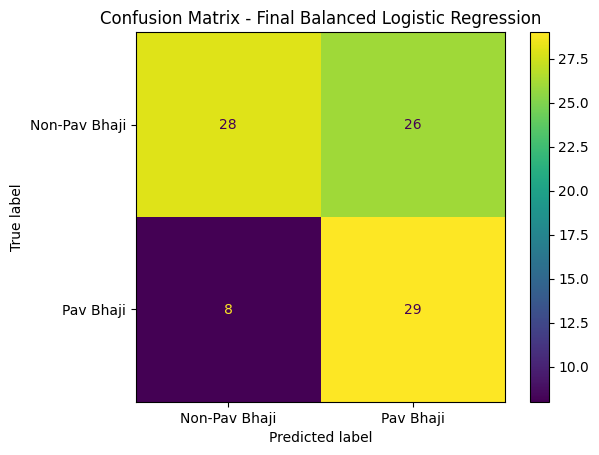

In [31]:
# Final confusion matrix for the selected model

cm_final = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Non-Pav Bhaji", "Pav Bhaji"]
)

disp.plot()
plt.title("Confusion Matrix - Final Balanced Logistic Regression")
plt.show()

## 24. Results & Key Findings

The final model selected after the class-balance experiment is **Balanced Logistic Regression**.

On the held-out test set, it achieved:

- **Accuracy:** 0.626
- **Precision:** 0.527
- **Recall:** 0.784
- **F1-score:** 0.630

The final confusion matrix contains:

- **28** correctly classified Non-Pav Bhaji posts
- **26** Non-Pav Bhaji posts classified as Pav Bhaji
- **8** Pav Bhaji posts classified as Non-Pav Bhaji
- **29** correctly classified Pav Bhaji posts

The main practical result is the **0.784 recall for the Pav Bhaji class**. The model identifies most of the Pav Bhaji samples in the test set, although the precision of 0.527 shows that it also produces a noticeable number of false Pav Bhaji predictions.

The feature coefficients show that food-related words and contextual terms in captions and hashtags provide useful signals. At the same time, the errors confirm the limitation of a metadata-only approach: without image pixels, some posts cannot be separated reliably from their text alone.

## 25. Conclusion

The final notebook provides an end-to-end solution for the given metadata-based classification task. I built the labelled dataset from the supplied image labels and Instagram metadata, cleaned the text, generated TF-IDF features, compared multiple classifiers, applied feature selection, handled class imbalance and evaluated the final model on a held-out test set.

The final **Balanced Logistic Regression** model achieved an F1-score of **0.630** and recall of **0.784** for the Pav Bhaji class. This shows that the Instagram metadata contains meaningful classification signals.

The main limitation is also clear from the results: the model does not analyse image pixels. Posts with weak, generic or misleading captions/hashtags can therefore be misclassified. For the current objective, the result demonstrates that a lightweight text-based approach can extract useful information from the supplied Instagram metadata without using a CNN-based image classifier.

Overall, the notebook focuses on a complete and reproducible ML workflow rather than only reporting a single accuracy value.